# QAOA for Graph Clustering · NumPy & SciPy

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
import networkx as nx
from numba import njit

Construct a graph for community detecting using networkx:

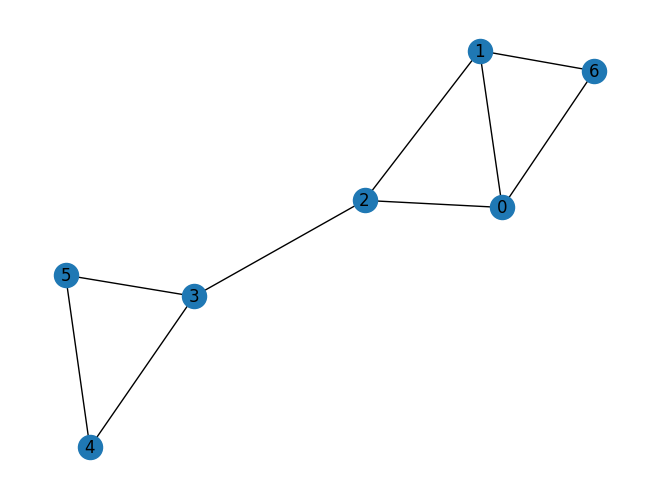

In [2]:
def add_edges(graph: nx.Graph, edges: list):
    for edge in edges:
        graph.add_edge(edge[0], edge[1])

network_graph = nx.Graph()
edges = [(0, 1), (0, 2), (0, 6), (1, 2), (1, 6), (2, 3), (3, 4), (3, 5), (4, 5)]

add_edges(network_graph, edges)
nodelist = sorted(network_graph.nodes())
A = np.array(nx.adjacency_matrix(network_graph, nodelist=nodelist).todense())

nx.draw(network_graph, with_labels=True)
plt.show()

Collect basic information about the graph and define the pauli matrices for Hamiltonian creation

In [3]:
N_QUBITS = len(network_graph.nodes)
DIM = 2 ** N_QUBITS

# Pauli matrices
I2 = np.eye(2, dtype=complex)
Zp = np.array([[1, 0], [0, -1]], dtype=complex)

## From Modularity to the Ising Hamiltonian

We construct the coupling coefficients $J_{ij}$ and the constant offset for the $k=2$ clustering Ising Hamiltonian:

$$H = \sum_{ij} J_{ij} s_i s_j$$

### Modularity

Modularity $Q$ is a scalar measure of the quality of a graph partitioning. It compares the actual edge density within clusters to the edge density one would expect in a random graph with the same degree sequence. A high modularity indicates dense intra-cluster connections and sparse inter-cluster connections, with $Q \in [-0.5, 1]$ and values above $\sim 0.3$ generally considered significant community structure.

It is defined as:

$$Q = \frac{1}{2m} \sum_{ij} \left(A_{ij} - \frac{k_i k_j}{2m}\right) \delta(s_i, s_j)$$

where:
- $A_{ij}$ is the adjacency matrix of the graph
- $k_i = \sum_j A_{ij}$ is the degree of node $i$
- $m = \frac{1}{2}\sum_{ij} A_{ij}$ is the total number of edges
- $\delta(s_i, s_j)$ is the Kronecker delta, ensuring only nodes belonging to the same cluster contribute

### Mapping to the Ising Hamiltonian

For $k=2$ clusters we assign each node a spin variable $s_i \in \{-1, +1\}$, where the two values encode cluster membership. This binary structure means we need only $n$ qubits — one per node — rather than the $k \cdot n$ qubits required in a general $k$-cluster formulation with super nodes.

Using the identity $\delta(s_i, s_j) = \frac{s_i s_j + 1}{2}$, the modularity becomes:

$$H = \frac{1}{2m} \sum_{ij} \left(A_{ij} - \frac{k_i k_j}{2m}\right) \frac{s_i s_j + 1}{2}$$

Expanding this expression separates into a constant term (independent of spin configuration) and an interaction term. Maximizing $Q$ is therefore equivalent to minimizing the Ising Hamiltonian over spin assignments, which is the problem QAOA is designed to tackle.

In [4]:
def ising_hamiltonian_k2_modularity(A: np.array, alpha: float) -> np.array:
    """
    Get the Ising Hamiltonian matrix J and constant shift for the k=2 
    modularity problem (special "easy" case).
    """
    num_nodes = len(A)
    m = np.sum(A) / 2
    k = A.sum(axis=1)                          
    B = (A - alpha * np.outer(k, k) / (2 * m)) / (2 * m)
    J = np.zeros((num_nodes, num_nodes))
    const = 0.0

    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            J[i, j] += B[i, j]
        const += B[i, i]

    return J, const / 2

## Validation of the Modularity Hamiltonian

Before proceeding with QAOA, we validate the Ising Hamiltonian formulation by cross-checking it against two references:

1. **Direct modularity function** — a straightforward implementation of $Q$ using the original definition, summing over all node pairs with the Kronecker delta
2. **NetworkX** — `networkx.algorithms.community.quality.modularity`, which serves as a well-tested ground truth

All three methods should return identical $Q$ values for any given graph and partition, up to floating point precision. This ensures that the $J_{ij}$ coefficients and constant offset are correctly derived before they are embedded into the quantum circuit.

In [5]:
from itertools import product

def modularity_calc(A: np.array, alpha: float, x: np.array) -> float: 
    """
    Calculate the modularity of a given partition x for the adjacency matrix A and resolution parameter alpha.
    """
    num_nodes = len(A)
    m = np.sum(A) / 2

    k = np.zeros(num_nodes)
    for i in range(num_nodes):
        k[i] = np.sum(A[i])

    modularity = 0.0
    for i in range(num_nodes):
        for j in range(num_nodes):
            if x[i] == x[j]:
                modularity += A[i, j] - alpha*(k[i] * k[j]) / (2 * m)
            
    return modularity / (2 * m)

H, const = ising_hamiltonian_k2_modularity(A, alpha=1.0)

print("2-cluster modularity testing for the Ising Hamiltonian: \n")
print("-----------------------------\n")

for x in product(range(2), repeat=N_QUBITS - 1):
    x_full = np.array([0] + list(x), dtype=int)

    z_full = np.array([2*x_i - 1 for x_i in x_full])

    obj_val = modularity_calc(A, alpha=1.0, x=x_full)
    networkx_modularity = nx.algorithms.community.quality.modularity(network_graph, [np.where(x_full == 0)[0].tolist(), np.where(x_full == 1)[0].tolist()])
    H_modularity = z_full @ H @ z_full + const  

    print(f"State: {x_full}  Mod: {obj_val:.4f}     Netx: {networkx_modularity:.4f}    H: {H_modularity:.4f}")

    # Check if all the modularity calculations match
    assert np.isclose(obj_val, networkx_modularity), f"Modularity mismatch for state {x_full}"
    assert np.isclose(obj_val, H_modularity), f"Hamiltonian modularity mismatch for state {x_full}"

2-cluster modularity testing for the Ising Hamiltonian: 

-----------------------------

State: [0 0 0 0 0 0 0]  Mod: 0.0000     Netx: 0.0000    H: 0.0000
State: [0 0 0 0 0 0 1]  Mod: -0.0247     Netx: -0.0247    H: -0.0247
State: [0 0 0 0 0 1 0]  Mod: -0.0247     Netx: -0.0247    H: -0.0247
State: [0 0 0 0 0 1 1]  Mod: -0.0988     Netx: -0.0988    H: -0.0988
State: [0 0 0 0 1 0 0]  Mod: -0.0247     Netx: -0.0247    H: -0.0247
State: [0 0 0 0 1 0 1]  Mod: -0.0988     Netx: -0.0988    H: -0.0988
State: [0 0 0 0 1 1 0]  Mod: 0.1235     Netx: 0.1235    H: 0.1235
State: [0 0 0 0 1 1 1]  Mod: 0.0000     Netx: 0.0000    H: -0.0000
State: [0 0 0 1 0 0 0]  Mod: -0.0556     Netx: -0.0556    H: -0.0556
State: [0 0 0 1 0 0 1]  Mod: -0.1543     Netx: -0.1543    H: -0.1543
State: [0 0 0 1 0 1 0]  Mod: 0.0679     Netx: 0.0679    H: 0.0679
State: [0 0 0 1 0 1 1]  Mod: -0.0802     Netx: -0.0802    H: -0.0802
State: [0 0 0 1 1 0 0]  Mod: 0.0679     Netx: 0.0679    H: 0.0679
State: [0 0 0 1 1 0 1]  Mod:

## Constructing the Cost Hamiltonian from Pauli Operators

With the Ising formulation validated, we now lift the classical spin Hamiltonian into the quantum setting. The spin variables $s_i \in \{-1, +1\}$ are promoted to quantum operators by replacing each with the Pauli-$Z$ operator acting on qubit $i$:

$$s_i \rightarrow Z_i, \qquad Z_i = \underbrace{I \otimes \cdots \otimes I}_{i-1} \otimes \sigma_z \otimes \underbrace{I \otimes \cdots \otimes I}_{n-i-1}$$

The two-spin interaction terms $s_i s_j$ become two-qubit $ZZ$ operators:

$$s_i s_j \rightarrow Z_i Z_j$$

The full cost Hamiltonian acting on the $n$-qubit Hilbert space is then:

$$H_C = C \cdot I + \sum_{i < j} J_{ij}\, Z_i Z_j$$

where $C$ is the constant offset inherited from the modularity expansion. Since $H_C$ is diagonal in the computational basis, its eigenvalues correspond directly to the modularity values of all $2^n$ spin configurations, and the ground state encodes the optimal two-cluster partition.

In [6]:
def kron_op(op: np.ndarray, qubit: int, n_qubits: int) -> np.ndarray:
    """
    Embed single-qubit op on 'qubit' in n-qubit space.
    """
    ops = [I2] * n_qubits
    ops[qubit] = op 
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def kron_two(op_i: np.ndarray, qi: int, op_j: np.ndarray, qj: int, n_qubits: int) -> np.ndarray:
    """
    Embed two single-qubit operators on different qubits.
    """
    ops = [I2] * n_qubits
    ops[qi] = op_i
    ops[qj] = op_j
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def pauli_z_hamiltonian_k2_modularity(A: np.array, alpha: float) -> np.array:
    """
    The full 2^n x 2^n Hamiltonian matrix for the k=2 modularity problem, expressed in the computational basis.
    This is a sum of ZZ terms with coefficients from the Ising Hamiltonian, plus a constant shift.
    """
    num_nodes = len(A)
    DIM = 2 ** num_nodes
    H_C = np.zeros((DIM, DIM), dtype=complex)
    J, const = ising_hamiltonian_k2_modularity(A, alpha)

    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            ZZ = kron_two(Zp, i, Zp, j, num_nodes)
            H_C += J[i, j] * ZZ

    np.set_printoptions(precision=4, suppress=True)
    # print(H_C[:8, :8].real)

    H_C += const * np.eye(DIM, dtype=complex)
    # print(H_C[:8, :8].real)

    return H_C

Enusre correct ordering of the qubits: 

In [7]:
n = 3
ZZ_01 = kron_two(Zp, 0, Zp, 1, n)
Z_Z_I = np.kron(np.kron(Zp, Zp), I2)
print(np.allclose(ZZ_01, Z_Z_I))

ZZ_06 = kron_two(Zp, 0, Zp, 6, 7)
Z_I5_Z = np.kron(np.kron(Zp, np.eye(32)), Zp)
print(np.allclose(ZZ_06, Z_I5_Z))

True
True


We validate the Pauli Hamiltonian formulation by cross-checking it against the networkx modularity calculation and the Ising Hamiltoian. 

In [8]:
def bitstring_energy(H_C: np.ndarray, x: np.array) -> float:
    """
    Get energy of a computational basis state from the Pauli-Z Hamiltonian.
    x: binary array of length n, e.g. [0, 1, 0, 1]
    """
    n = len(x)
    # Encode bitstring to matrix index: qubit 0 = most significant bit
    idx = sum(int(x[i]) * (2 ** (n - 1 - i)) for i in range(n))
    return H_C[idx, idx].real

H_C = pauli_z_hamiltonian_k2_modularity(A, alpha=1.0)
cost_diag = np.diag(H_C).real

print("2-cluster modularity testing for the Pauli Hamiltonian: \n")
print("-----------------------------\n")

for x in product(range(2), repeat=N_QUBITS - 1):
    x_full = np.array([0] + list(x), dtype=int)

    z_full = np.array([2*x_i - 1 for x_i in x_full])

    networkx_modularity = nx.algorithms.community.quality.modularity(network_graph, [np.where(x_full == 0)[0].tolist(), np.where(x_full == 1)[0].tolist()])
    H_org = z_full @ H @ z_full + const
    H_modularity = bitstring_energy(H_C, x_full)  # Get energy from the Pauli-Z Hamiltonian

    print(f"State: {x_full}  Netx: {networkx_modularity:.4f}    H_org: {H_org:.4f}    H: {H_modularity:.4f}")

    # Check if all the modularity calculations match
    assert np.isclose(networkx_modularity, H_modularity), f"Hamiltonian modularity mismatch for state {x_full}"


2-cluster modularity testing for the Pauli Hamiltonian: 

-----------------------------

State: [0 0 0 0 0 0 0]  Netx: 0.0000    H_org: 0.0000    H: 0.0000
State: [0 0 0 0 0 0 1]  Netx: -0.0247    H_org: -0.0247    H: -0.0247
State: [0 0 0 0 0 1 0]  Netx: -0.0247    H_org: -0.0247    H: -0.0247
State: [0 0 0 0 0 1 1]  Netx: -0.0988    H_org: -0.0988    H: -0.0988
State: [0 0 0 0 1 0 0]  Netx: -0.0247    H_org: -0.0247    H: -0.0247
State: [0 0 0 0 1 0 1]  Netx: -0.0988    H_org: -0.0988    H: -0.0988
State: [0 0 0 0 1 1 0]  Netx: 0.1235    H_org: 0.1235    H: 0.1235
State: [0 0 0 0 1 1 1]  Netx: 0.0000    H_org: -0.0000    H: -0.0000
State: [0 0 0 1 0 0 0]  Netx: -0.0556    H_org: -0.0556    H: -0.0556
State: [0 0 0 1 0 0 1]  Netx: -0.1543    H_org: -0.1543    H: -0.1543
State: [0 0 0 1 0 1 0]  Netx: 0.0679    H_org: 0.0679    H: 0.0679
State: [0 0 0 1 0 1 1]  Netx: -0.0802    H_org: -0.0802    H: -0.0802
State: [0 0 0 1 1 0 0]  Netx: 0.0679    H_org: 0.0679    H: 0.0679
State: [0 0 0 

Important note!: 
The qubit ordering is as follows: 
qubit 0 is the leftmost kron factor, ops[0] or the most significant bit (MSB)

## The QAOA Circuit

The Quantum Approximate Optimization Algorithm prepares a parameterized quantum state by alternating between two unitary operators applied to an initial uniform superposition:

$$|\psi_p(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle = \prod_{k=1}^{p} e^{-i\beta_k H_M} e^{-i\gamma_k H_C} |+\rangle^{\otimes n}$$

where:
- $|+\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}}\sum_{x \in \{0,1\}^n} |x\rangle$ is the uniform superposition over all $2^n$ computational basis states, serving as the initial state
- $e^{-i\gamma_k H_C}$ is the **phase separation unitary**, encoding the cost function into the phases of the state
- $e^{-i\beta_k H_M}$ is the **mixing unitary**, with mixer Hamiltonian $H_M = \sum_{i=1}^n X_i$, driving transitions between basis states and preventing the optimizer from getting trapped
- $\boldsymbol{\gamma}, \boldsymbol{\beta} \in [0, \pi]^p$ are the variational parameters
- $p$ is the circuit depth, controlling the expressibility of the ansatz — larger $p$ allows finer optimization at the cost of more parameters

### Variational Objective

The variational parameters are optimized by maximizing the expectation value of the cost Hamiltonian:

$$F_p(\boldsymbol{\gamma}, \boldsymbol{\beta}) = \langle \psi_p | H_C | \psi_p \rangle$$

This is the quantity returned by the statevector simulation at each step of the classical optimizer. Maximizing $F_p$ pushes the state toward computational basis states with high modularity, with the exact ground state recovered in the limit $p \rightarrow \infty$.

### Implementing the Unitaries

Since $H_C$ is already constructed as a full $2^n \times 2^n$ matrix, the cost unitary $e^{-i\gamma H_C}$ is obtained directly via matrix exponentiation. The mixer Hamiltonian $H_M = \sum_i X_i$ decomposes into a tensor product of single-qubit rotations, since all terms commute:

$$e^{-i\beta H_M} = \bigotimes_{i=0}^{n-1} e^{-i\beta X_i} = \bigotimes_{i=0}^{n-1} R_X(2\beta)$$

This makes the mixer unitary cheap to apply — rather than exponentiating the full $2^n \times 2^n$ mixer matrix, we can apply single-qubit $R_X$ rotations qubit by qubit via successive Kronecker products, which is what `apply_mixer` exploits.

In [9]:
def apply_cost_unitary(state: np.ndarray, gamma: float) -> np.ndarray:
    return np.exp(-1j * gamma * cost_diag) * state  # O(n) elementwise

def apply_mixer(state: np.ndarray, beta: float, N_QUBITS: int) -> np.ndarray:
    c, s = np.cos(beta/2), np.sin(beta/2)
    mat = np.array([[c, -1j*s], [-1j*s, c]], dtype=complex)  # Rx(2β) up to convention
    state = state.reshape([2]*N_QUBITS)
    for q in range(N_QUBITS):
        state = np.tensordot(mat, state, axes=[[1], [q]])
        state = np.moveaxis(state, 0, q)
    return state.reshape(-1)

Main functions for running the QAOA

In [10]:
def qaoa_run(p: int, params: np.ndarray, N_QUBITS: int) -> np.ndarray:
    gammas, betas = params[:p], params[p:]
    dim = 2**N_QUBITS
    state = np.ones(dim, dtype=complex) / np.sqrt(dim)
    for k in range(p):
        state = apply_cost_unitary(state, gammas[k])   
        state = apply_mixer(state, betas[k], N_QUBITS) 
    return state

def expectation_value(p: int, params: np.ndarray, N_QUBITS: int) -> float:
    state = qaoa_run(p, params, N_QUBITS)
    return float(np.real(np.dot(cost_diag, np.abs(state)**2))) 

## Optimizing the Variational Parameters

We optimize the variational parameters $(\boldsymbol{\gamma}, \boldsymbol{\beta})$ using SciPy's `minimize` with the **COBYLA** optimizer — a gradient-free method well suited for noisy or non-differentiable objective landscapes, as is typical in variational quantum algorithms.

For each circuit depth $p \in \{1, 2, 3\}$ we minimize the negative expectation value:

$$\mathcal{L}(\boldsymbol{\gamma}, \boldsymbol{\beta}) = -F_p(\boldsymbol{\gamma}, \boldsymbol{\beta}) = -\langle \psi_p | H_C | \psi_p \rangle$$

with $2p$ free parameters initialized randomly in $[0, \pi]^{2p}$ at each restart.

A few things to keep in mind:

- **Random initialization** is important because the QAOA landscape is generally non-convex and contains many local optima, particularly at low $p$. Multiple random restarts help mitigate this.
- **Symmetry of the solution** — since there is no physical difference between labelling a cluster $0$ or $1$, any optimal partition $\mathbf{s}^*$ and its bitwise complement $\bar{\mathbf{s}}^*$ are degenerate solutions with identical modularity. This $\mathbb{Z}_2$ symmetry means the optimizer may converge to either, and both should be treated as equally valid.
- **Increasing $p$** gives the ansatz more expressibility and generally yields higher $F_p$, at the cost of a larger parameter space and more circuit evaluations per optimization step.

In [14]:
# Optimise for different p's using COBYLA with random restarts
results = {}
print('Optimising QAOA parameters:\n')

for p in [1, 2, 3]:
    best_val = np.inf
    best_res = None
    n_restarts = 100 if p == 1 else 300

    for _ in range(n_restarts):
        g0 = np.random.uniform(0, np.pi,    p)
        b0 = np.random.uniform(0, np.pi/2,  p)
        x0 = np.concatenate([g0, b0])
        res = minimize(lambda params: -expectation_value(p, params, N_QUBITS), x0,
                       method='COBYLA', options={'maxiter': 2000, 'rhobeg': 0.5})
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    energy     = -best_val
    psi_opt    = qaoa_run(p, best_res.x, N_QUBITS)
    probs_opt  = np.abs(psi_opt) ** 2

    results[p] = {'params': best_res.x, 'energy': energy,
                  'probs': probs_opt, 'state': psi_opt}

    print(f'  p={p}: E={energy:.4f}  params={best_res.x}')
    print(f'  Probabilities of top 5 bitstrings:')
    top_indices = np.argsort(probs_opt)[-5:][::-1]
    for idx in top_indices:
        print(f'    {idx:0{N_QUBITS}b}  Prob={probs_opt[idx]:.4f}')

    # Find the most probable bitstring and print it
    most_probable = np.argmax(probs_opt)
    print(f'  Most probable bitstring: {most_probable:0{N_QUBITS}b}  Prob={probs_opt[most_probable]:.4f}\n')
          



Optimising QAOA parameters:

  p=1: E=0.1366  params=[8.5139 0.9621]
  Probabilities of top 5 bitstrings:
    1110001  Prob=0.1462
    0001110  Prob=0.1462
    0011110  Prob=0.0659
    1100001  Prob=0.0659
    1110000  Prob=0.0231
  Most probable bitstring: 0001110  Prob=0.1462

  p=2: E=0.2672  params=[6.9338 9.4783 1.3526 0.792 ]
  Probabilities of top 5 bitstrings:
    1110001  Prob=0.3134
    0001110  Prob=0.3134
    0011110  Prob=0.0880
    1100001  Prob=0.0880
    1110000  Prob=0.0076
  Most probable bitstring: 0001110  Prob=0.3134

  p=3: E=0.3306  params=[5.5022 8.0191 8.8114 1.2844 1.0954 0.5788]
  Probabilities of top 5 bitstrings:
    1110001  Prob=0.4048
    0001110  Prob=0.4048
    0011110  Prob=0.0682
    1100001  Prob=0.0682
    1110000  Prob=0.0032
  Most probable bitstring: 0001110  Prob=0.4048



Brute-force optimal k-cluster modularity Q calculation: 

-----------------------------


Optimal 2-cluster partition (Q = 0.3642)
  Cluster 0 (4 nodes): [0, 1, 2, 6]
  Cluster 1 (3 nodes): [3, 4, 5]
  Labelling: [0, 0, 0, 1, 1, 1, 0]


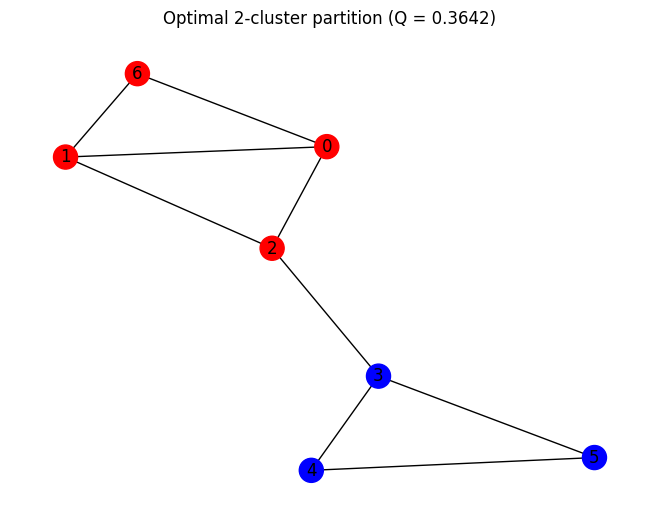

In [18]:
from itertools import product

print("Brute-force optimal k-cluster modularity Q calculation: \n")
print("-----------------------------\n")

n_clusters = 2
best_val = -np.inf
best_config = None

for x in product(range(n_clusters), repeat=N_QUBITS - 1):
    x_full = np.array([0] + list(x), dtype=int)

    if len(np.unique(x_full)) < n_clusters:
        continue

    obj_val = modularity_calc(A, alpha=1.0, x=x_full)
    if obj_val > best_val:
        best_val = obj_val
        best_config = x_full.copy()

print(f"\nOptimal {n_clusters}-cluster partition (Q = {best_val:.4f})")
for c in range(n_clusters):
    nodes = np.where(best_config == c)[0].tolist()
    print(f"  Cluster {c} ({len(nodes)} nodes): {nodes}")
print(f"  Labelling: {best_config.tolist()}")

cmap = ['red', 'blue', 'green', 'orange', 'purple']
node_order = list(network_graph.nodes())
color_map = [cmap[best_config[i]] for i in node_order]
plt.figure()
nx.draw(network_graph, with_labels=True, node_color=color_map)
plt.title(
    f"Optimal {n_clusters}-cluster partition (Q = {best_val:.4f})"
)
plt.show()

In [34]:
class QAOAClustering:
    def __init__(self, A: np.ndarray, alpha: float):
        self.A = A
        self.alpha = alpha
        self.N_QUBITS = len(A)
        self.dim = 2 ** self.N_QUBITS
        self.qubit_shape = [2] * self.N_QUBITS
        self.cost_diag = np.diag(pauli_z_hamiltonian_k2_modularity(A, alpha=alpha)).real
        self.state = None
        self._Rx_cache = {}  # cache Rx matrices by beta value

    def apply_cost_unitary(self, gamma: float):
        self.state = np.exp(-1j * gamma * self.cost_diag) * self.state

    def apply_mixer(self, beta: float):
        c, s = np.cos(beta / 2), np.sin(beta / 2)
        mat = np.array([[c, -1j * s], [-1j * s, c]], dtype=complex)
        self.state = self.state.reshape(self.qubit_shape)
        for q in range(self.N_QUBITS):
            self.state = np.tensordot(mat, self.state, axes=[[1], [q]])
            self.state = np.moveaxis(self.state, 0, q)
        self.state = self.state.reshape(self.dim)

    def qaoa_run(self, p: int, params: np.ndarray):
        gammas, betas = params[:p], params[p:]
        self.state = np.ones(self.dim, dtype=complex) / np.sqrt(self.dim)
        for k in range(p):
            self.apply_cost_unitary(gammas[k])
            self.apply_mixer(betas[k])

    def expectation_value(self, p: int, params: np.ndarray) -> float:
        self.qaoa_run(p, params)
        return float(np.dot(self.cost_diag, np.abs(self.state) ** 2))
    
    def get_most_probable_bitstring(self) -> str:
        if self.state is None:
            raise ValueError("QAOA state not computed yet. Run qaoa_run() first.")
        probs = np.abs(self.state) ** 2
        most_probable_idx = np.argmax(probs)
        return format(most_probable_idx, f'0{self.N_QUBITS}b')

In [35]:
def partition_into_clusters(A: np.array, bitstring: str) -> tuple[np.array, np.array]: 
    n = A.shape[0]
    C0_size = np.count_nonzero(bitstring == 0)
    C1_size = np.count_nonzero(bitstring == 1)

    C0 = np.zeros((C0_size, C0_size))
    C1 = np.zeros((C1_size, C1_size))

    local_idx_0 = np.cumsum(bitstring == 0) - 1
    local_idx_1 = np.cumsum(bitstring == 1) - 1

    for i in range(n):
        for j in range(i+1, n): 
            if bitstring[i] == 0 and bitstring[j] == 0: 
                C0[local_idx_0[i], local_idx_0[j]] = A[i, j]
                C0[local_idx_0[j], local_idx_0[i]] = A[i, j]
            elif bitstring[i] == 1 and bitstring[j] == 1:
                C1[local_idx_1[i], local_idx_1[j]] = A[i, j]
                C1[local_idx_1[j], local_idx_1[i]] = A[i, j]
    return C0, C1

def qaoa_k2_cluster(A: np.array, alpha: float, p: int, n_restarts: int, primitive_result: bool = True) -> dict:
    k2_cluster = QAOAClustering(A, alpha=alpha)

    best_val = np.inf
    best_res = None

    advanced_results = {'gammas': [], 'betas': [], 'energies': []}

    for _ in range(n_restarts):
        g0 = np.random.uniform(0, np.pi,    p)
        b0 = np.random.uniform(0, np.pi/2,  p)
        x0 = np.concatenate([g0, b0])
        res = minimize(lambda params: -k2_cluster.expectation_value(p, params), x0,
                    method='COBYLA', options={'maxiter': 200, 'rhobeg': 0.5})
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

        if not primitive_result:
            advanced_results['gammas'].append(res.x[:p])
            advanced_results['betas'].append(res.x[p:])
            advanced_results['energies'].append(-res.fun)

    k2_cluster.qaoa_run(p, best_res.x)
    probs_opt  = np.abs(k2_cluster.state) ** 2

    if primitive_result: 
        results = {'params': best_res.x,
                    'probs': probs_opt, 
                    'best_partition': k2_cluster.get_most_probable_bitstring()}
    else: 
        results = {'params': best_res.x,
                    'probs': probs_opt, 
                    'best_partition': k2_cluster.get_most_probable_bitstring(),
                    'advanced': advanced_results}

    return results
    

In [42]:
def k_cluster_qaoa(A: np.array):
    # This function would implement the QAOA for k-cluster modularity optimization.
    # It uses the 2-cluster cost Hamiltonian to segment the graph into more and more clusters.
    # Step 1: Get the 2-cluster Pauli-Z Hamiltonian H_C for the modularity problem and solve it with QAOA.
    p=1
    k2_results = qaoa_k2_cluster(A, alpha=1.0, p=p, n_restarts=2)
    k2_config = np.array(list(k2_results["best_partition"]), dtype=int)
    best_modularity = modularity_calc(A, alpha=1.0, x=k2_config)

    print(f'  p={p}: params={k2_results["params"]}')
    print(f'  Probabilities of top 2 bitstrings:')
    top_indices = np.argsort(k2_results["probs"])[-2:][::-1]
    for idx in top_indices: 
        print(f'    {idx:0{N_QUBITS}b}  Prob={k2_results["probs"][idx]:.4f}')

    bitstring = k2_results["best_partition"]
    k2_config = np.array(list(bitstring), dtype=int)
    
    C0, C1 = partition_into_clusters(A, k2_config)
    print(f'Cluster 0: \n {C0} \nCluster 1: \n {C1}')

    C0_results = qaoa_k2_cluster(C0, alpha=2.0, p=p, n_restarts=2)
    C1_results = qaoa_k2_cluster(C1, alpha=2.0, p=p, n_restarts=2)

    C0_config = np.array(list(C0_results["best_partition"]), dtype=int)
    C1_config = np.array(list(C1_results["best_partition"]), dtype=int)

    print(f'Modularity of C0 partition: {modularity_calc(C0, alpha=2.0, x=C0_config):.4f}')
    print(f'Modularity of C1 partition: {modularity_calc(C1, alpha=2.0, x=C1_config):.4f}')

    # Combine the results from the subclusters to form a new partition of the 
    # original graph, and calculate its modularity.
    print(f'C_0 result: {C0_results["best_partition"]}, \n C_1 result: {C1_results["best_partition"]}')

    k2_C0_config = np.zeros(len(A), dtype=int)
    k2_C1_config = np.zeros(len(A), dtype=int)

    c0 = 0
    c1 = 0

    for i in range(len(A)):
        if k2_config[i] == 0:
            k2_C0_config[i] = C0_config[c0] + 1
            c0 += 1
        else:
            k2_C1_config[i] = C1_config[c1] + 1
            c1 += 1

    c0_modularity = modularity_calc(A, alpha=1.0, x=k2_C0_config)
    c1_modularity = modularity_calc(A, alpha=1.0, x=k2_C1_config)

    print(f'Combined partition C0: {k2_C0_config} with modularity {c0_modularity:.4f}')
    print(f'Combined partition C1: {k2_C1_config} with modularity {c1_modularity:.4f}')

    if c0_modularity > best_modularity:
        print(f'  Found better modularity with C0 partition: {c0_modularity:.4f} (previous best was {best_modularity:.4f})')
        best_modularity = c0_modularity
        best_config = k2_C0_config.copy()
    if c1_modularity > best_modularity:
        print(f'  Found better modularity with C1 partition: {c1_modularity:.4f} (previous best was {best_modularity:.4f})')
        best_modularity = c1_modularity
        best_config = k2_C1_config.copy()

k_cluster_qaoa(A)


  p=1: params=[8.4678 0.961 ]
  Probabilities of top 2 bitstrings:
    1110001  Prob=0.1461
    0001110  Prob=0.1461
Cluster 0: 
 [[0. 1. 1. 1.]
 [1. 0. 1. 1.]
 [1. 1. 0. 0.]
 [1. 1. 0. 0.]] 
Cluster 1: 
 [[0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 0.]]
Modularity of C0 partition: -0.6000
Modularity of C1 partition: -0.7778
C_0 result: 0110, 
 C_1 result: 001
Combined partition C0: [1 2 2 0 0 0 1] with modularity 0.2160
Combined partition C1: [0 0 0 1 1 2 0] with modularity 0.2037


In [43]:
def k_cluster_qaoa(
    A: np.ndarray,
    p: int = 1,
    n_restarts: int = 3,
    alpha_scale: float = 1.5,
    min_cluster_size: int = 2,
    max_depth: int = 4,
) -> dict:
    """
    Hierarchical bisection clustering using QAOA.

    At each step the 2-cluster QAOA is applied to a subgraph. If the split
    improves the global modularity of the original graph A, the cluster is
    accepted and each half is recursively bisected. alpha is scaled up at
    each depth level to incentivise partitioning of increasingly tight
    subgraphs.

    Parameters
    ----------
    A             : Adjacency matrix of the original graph (never changes).
    p             : QAOA circuit depth.
    n_restarts    : Number of random restarts for the QAOA optimizer.
    alpha_scale   : Multiplicative increase of alpha per recursion depth.
    min_cluster_size : Stop splitting clusters smaller than this.
    max_depth     : Maximum recursion depth (= maximum number of bisections).

    Returns
    -------
    dict with keys:
        best_labels   : np.ndarray of shape (n,) with integer cluster labels
        best_modularity : float, global modularity of the best partition found
        tree          : nested dict recording every bisection attempted
    """

    n = len(A)
    # Global state shared across all recursive calls
    state = {
        "best_labels": np.zeros(n, dtype=int),
        "best_modularity": modularity_calc(A, alpha=1.0, x=np.zeros(n, dtype=int)),
        "n_clusters": 1,
        "tree": {},
    }

    def _bisect(
        subA: np.ndarray,
        global_indices: np.ndarray,
        current_labels: np.ndarray,
        depth: int,
        alpha: float,
        node_key: str,
    ) -> None:
        """
        Recursively bisect a subgraph.

        subA           : Adjacency matrix of the current subgraph.
        global_indices : Which nodes of the original graph this subgraph contains.
        current_labels : Full n-length label array at this point in the tree.
        depth          : Current recursion depth.
        alpha          : Alpha passed to QAOA for this subgraph.
        node_key       : String key identifying this node in the tree dict.
        """
        sub_n = len(subA)
        tree_node = {
            "depth": depth,
            "alpha": alpha,
            "global_indices": global_indices.tolist(),
            "sub_n": sub_n,
            "split_accepted": False,
            "children": {},
        }
        state["tree"][node_key] = tree_node

        # Base cases — do not split
        if sub_n < min_cluster_size or depth >= max_depth:
            return

        # Run 2-cluster QAOA on this subgraph
        results = qaoa_k2_cluster(subA, alpha=alpha, p=p, n_restarts=n_restarts)
        local_config = np.array(list(results["best_partition"]), dtype=int)
        tree_node["qaoa_results"] = {
            "params": results["params"],
            "local_config": local_config.tolist(),
            "probs": results["probs"].tolist(),
        }

        # Check that both sides are non-empty (valid split)
        mask0 = local_config == 0
        mask1 = local_config == 1
        if mask0.sum() == 0 or mask1.sum() == 0:
            tree_node["split_accepted"] = False
            return

        # Map local split back to global label array
        # Nodes in the sub-cluster labelled 1 get a new unique cluster id
        new_cluster_id = state["n_clusters"]
        proposed_labels = current_labels.copy()
        proposed_labels[global_indices[mask1]] = new_cluster_id

        global_modularity = modularity_calc(A, alpha=1.0, x=proposed_labels)
        tree_node["proposed_modularity"] = float(global_modularity)
        tree_node["previous_modularity"] = float(state["best_modularity"])

        # Accept split only if it improves global modularity
        if global_modularity > state["best_modularity"]:
            state["best_modularity"] = global_modularity
            state["best_labels"] = proposed_labels.copy()
            state["n_clusters"] += 1
            tree_node["split_accepted"] = True

            print(
                f"[depth={depth}] Split accepted | "
                f"nodes {global_indices.tolist()} → "
                f"C{new_cluster_id-1}:{global_indices[mask0].tolist()} "
                f"C{new_cluster_id}:{global_indices[mask1].tolist()} | "
                f"Q={global_modularity:.4f}"
            )

            # Recurse into each child subgraph with increased alpha
            child_alpha = alpha * alpha_scale
            _bisect(
                subA=subA[np.ix_(mask0, mask0)],
                global_indices=global_indices[mask0],
                current_labels=proposed_labels,
                depth=depth + 1,
                alpha=child_alpha,
                node_key=f"{node_key}_C0",
            )
            _bisect(
                subA=subA[np.ix_(mask1, mask1)],
                global_indices=global_indices[mask1],
                current_labels=proposed_labels,
                depth=depth + 1,
                alpha=child_alpha,
                node_key=f"{node_key}_C1",
            )
        else:
            print(
                f"[depth={depth}] Split rejected | "
                f"nodes {global_indices.tolist()} | "
                f"Q={global_modularity:.4f} ≤ best={state['best_modularity']:.4f}"
            )

    # Kick off recursion from the full graph
    _bisect(
        subA=A,
        global_indices=np.arange(n),
        current_labels=state["best_labels"].copy(),
        depth=0,
        alpha=1.0,
        node_key="root",
    )

    print(f"\nFinal partition into {state['n_clusters']} clusters:")
    print(f"  Labels     : {state['best_labels'].tolist()}")
    print(f"  Modularity : {state['best_modularity']:.4f}")

    return {
        "best_labels": state["best_labels"],
        "best_modularity": state["best_modularity"],
        "n_clusters": state["n_clusters"],
        "tree": state["tree"],
    }

In [45]:
res = k_cluster_qaoa(A)

[depth=0] Split accepted | nodes [0, 1, 2, 3, 4, 5, 6] → C0:[0, 1, 2, 6] C1:[3, 4, 5] | Q=0.3642
[depth=1] Split rejected | nodes [0, 1, 2, 6] | Q=0.2160 ≤ best=0.3642

Final partition into 2 clusters:
  Labels     : [0, 0, 0, 1, 1, 1, 0]
  Modularity : 0.3642
